In [1]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
def extract_metric_values(criteria: str, strings: list[str]) -> np.ndarray:
    """Extracts float values from strings like 'Validation Loss: 1.747406'."""
    # return [float(s.split(criteria)[1]) for s in strings]
    return np.array([float(s.split(criteria)[1]) for s in strings])


def parse_training_log(file_path: str):
    """Parses a model training log file to extract per-epoch metrics:

    - Training Loss
    - Training Macro F1
    - Validation Loss
    - Validation Macro F1

    Returns a pandas DataFrame with the extracted metrics.
    """
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()

    pattern = r"Training Macro F1: \d+\.\d+"
    training_macro_f1_values = re.findall(pattern, content, flags=re.IGNORECASE)
    tranining_macro_f1_values = extract_metric_values("Training Macro F1: ", training_macro_f1_values)

    pattern = r"Training Loss: \d+\.\d+"
    training_loss_values = re.findall(pattern, content, flags=re.IGNORECASE)
    training_loss_values = extract_metric_values("Training Loss: ", training_loss_values)

    pattern = r"Validation Macro F1: \d+\.\d+"
    validation_macro_f1_values = re.findall(pattern, content, flags=re.IGNORECASE)
    validation_macro_f1_values = extract_metric_values("Validation Macro F1: ", validation_macro_f1_values)

    pattern = r"Validation Loss: \d+\.\d+"
    validation_loss_values = re.findall(pattern, content, flags=re.IGNORECASE)
    validation_loss_values = extract_metric_values("Validation Loss: ", validation_loss_values)

    pattern = r"Test Macro F1: \d+\.\d+"
    test_macro_f1 = re.findall(pattern, content, flags=re.IGNORECASE)
    test_macro_f1 = extract_metric_values("Test Macro F1: ", test_macro_f1)[0]

    pattern = r"Test Loss: \d+\.\d+"
    test_loss = re.findall(pattern, content, flags=re.IGNORECASE)
    test_loss = extract_metric_values("Test Loss: ", test_loss)[0]

    pattern = r"Test F1 Scores:(.*?)Test Macro F1:"
    match = re.search(pattern, content, flags=re.DOTALL | re.IGNORECASE)

    if match:
        extracted_text = match.group(1).strip()

    pattern = r"(\w+) F1: (\d+\.\d+)"
    matches = re.findall(pattern, extracted_text, flags=re.IGNORECASE)
    class_f1_scores = {relation: float(score) for relation, score in matches}

    train_val_data = {
        "training_loss": training_loss_values,
        "training_f1": tranining_macro_f1_values,
        "validation_loss": validation_loss_values,
        "validation_f1": validation_macro_f1_values,
    }

    test_data = {
        "test_loss": test_loss,
        "test_macro_f1": test_macro_f1,
        "class_f1_scores": class_f1_scores,
    }

    return train_val_data, test_data

In [3]:
df = pd.DataFrame({"method": ["baseline", "augmented", "constraints"]})

In [ ]:
data_dict = {}
modes = ["training", "validation"]
metrics = ["loss", "f1"]
methods = ["baseline", "augmented", "constraints"]
seeds = [0, 1, 2]
baseline = []
for method in methods:
    for metric in metrics:
        for mode in modes:
            scores = []
            for seed in seeds:
                data, _ = parse_training_log(f"../runs/{method}_seed_{seed}.out")
                scores.append(data[f"{mode}_{metric}"])   
            data_dict[f"{method}_{mode}_{metric}"] = sum(scores)/len(seeds)

[array([1.756518, 1.356818, 0.849695, 0.584497, 0.435574, 0.316279,
       0.25766 , 0.211073]), array([1.751122, 1.340868, 0.833068, 0.575784, 0.418078, 0.319156,
       0.255246, 0.225368]), array([1.752438, 1.376104, 0.874996, 0.606778, 0.43781 , 0.336143,
       0.26189 , 0.221946])]
[array([1.695556, 1.347296, 1.379056, 1.708765, 1.52815 , 1.895064,
       2.17056 , 2.831542]), array([1.681739, 1.358389, 1.413617, 1.861502, 1.928359, 2.146984,
       2.548446, 2.944102]), array([1.700832, 1.386571, 1.336497, 1.62933 , 1.676885, 2.17528 ,
       2.500246, 2.8862  ])]
[array([0.1774, 0.4206, 0.5783, 0.6614, 0.7276, 0.7899, 0.8211, 0.8412]), array([0.1976, 0.4172, 0.5865, 0.6688, 0.7284, 0.785 , 0.8143, 0.8366]), array([0.183 , 0.4027, 0.565 , 0.6655, 0.7332, 0.7776, 0.8143, 0.836 ])]
[array([0.2391, 0.4205, 0.4369, 0.4753, 0.4895, 0.4757, 0.469 , 0.4346]), array([0.2038, 0.4079, 0.4516, 0.4312, 0.4537, 0.4523, 0.4361, 0.4231]), array([0.2357, 0.3961, 0.4624, 0.4506, 0.4763, 0.4523, 

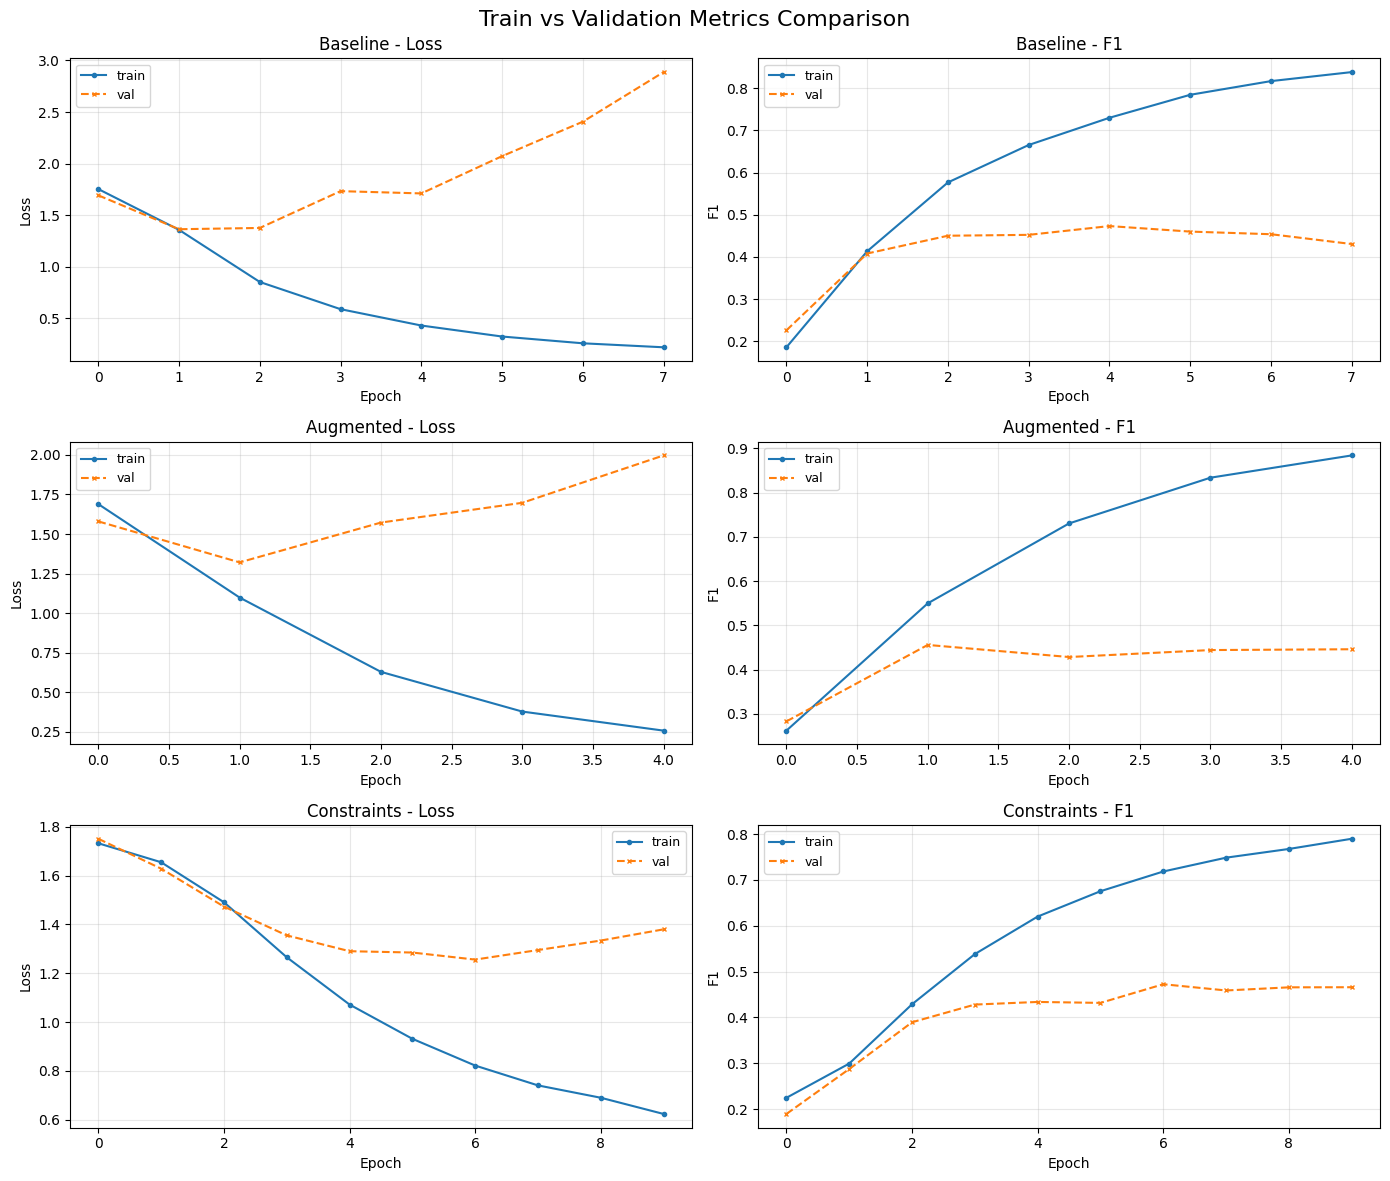

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Train vs Validation Metrics Comparison', fontsize=16)

metrics = ['loss', 'f1']
methods = ["baseline", "augmented", "constraints"]

for method_idx, method in enumerate(methods):
    for metric_idx, metric in enumerate(metrics):
        ax = axes[method_idx, metric_idx]
        
        train_key = f'{method}_training_{metric}'
        val_key = f'{method}_validation_{metric}'
        
        if train_key in data_dict and val_key in data_dict:
            train_data = data_dict[train_key]
            val_data = data_dict[val_key]
            epochs = range(len(train_data))
            
            # Plot train
            ax.plot(epochs, train_data, 
                   label='train', linestyle='-', marker='o', markersize=3)
            
            # Plot val
            ax.plot(epochs, val_data, 
                   label='val', linestyle='--', marker='x', markersize=3)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(f'{method.capitalize()} - {metric.capitalize()}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

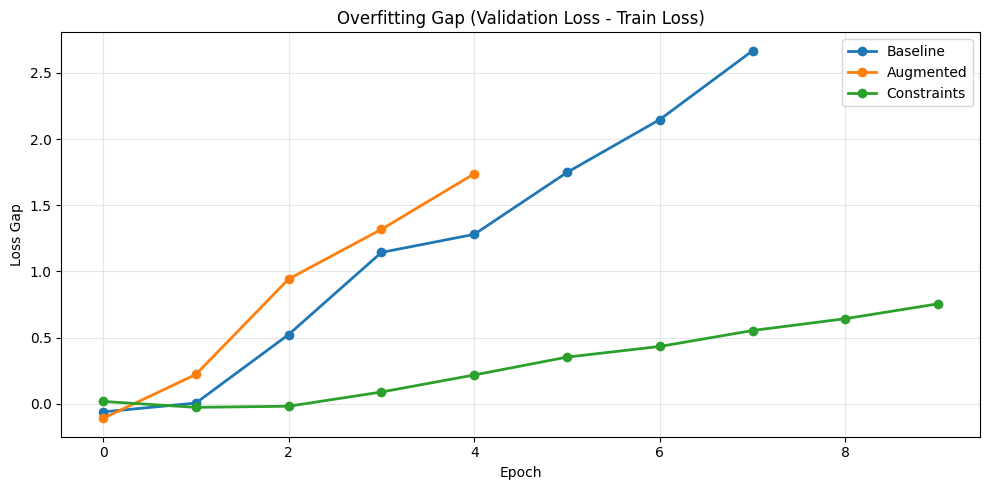

In [24]:
methods = ["baseline", "augmented", "constraints"]

# Compute gap for each method
gap_dict = {}

for method in methods:
    train_key = f'{method}_training_loss'
    val_key = f'{method}_validation_loss'
    
    if train_key in data_dict and val_key in data_dict:
        train_loss = data_dict[train_key]
        val_loss = data_dict[val_key]
        
        # Ensure same length
        epochs = min(len(train_loss), len(val_loss))
        train_loss = train_loss[:epochs]
        val_loss = val_loss[:epochs]
        
        # Gap = val_loss - train_loss (higher = more overfitting)
        gap = [v - t for v, t in zip(val_loss, train_loss)]
        gap_dict[method] = gap

# Plot Figure 2
plt.figure(figsize=(10, 5))
for method, gap in gap_dict.items():
    plt.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

plt.title("Overfitting Gap (Validation Loss - Train Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss Gap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=300, bbox_inches="tight")
plt.show()


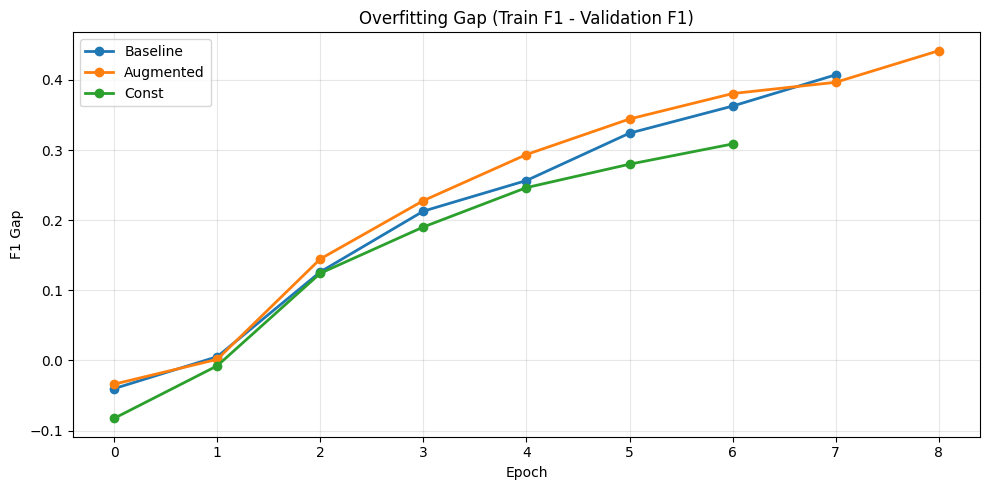

In [6]:
methods = ["baseline", "augmented", "const"]

# Compute F1 gap for each method
f1_gap_dict = {}

for method in methods:
    train_key = f'{method}_train_f1'
    val_key = f'{method}_val_f1'
    
    if train_key in data_dict and val_key in data_dict:
        train_f1 = data_dict[train_key]
        val_f1 = data_dict[val_key]
        
        # Ensure same length
        epochs = min(len(train_f1), len(val_f1))
        train_f1 = train_f1[:epochs]
        val_f1 = val_f1[:epochs]
        
        # Gap = train_f1 - val_f1 (higher = more overfitting)
        gap = [t - v for t, v in zip(train_f1, val_f1)]
        f1_gap_dict[method] = gap

# Plot F1 Gap
plt.figure(figsize=(10, 5))
for method, gap in f1_gap_dict.items():
    plt.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

plt.title("Overfitting Gap (Train F1 - Validation F1)")
plt.xlabel("Epoch")
plt.ylabel("F1 Gap")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("f1_overfitting_gap.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
methods = ["baseline", "augmented", "constraints"]

table_data = []

for method in methods:
    # Get F1 data
    train_f1_key = f'{method}_training_f1'
    val_f1_key = f'{method}_validation_f1'
    train_loss_key = f'{method}_training_loss'
    val_loss_key = f'{method}_validation_loss'
    
    if val_f1_key in data_dict:
        val_f1 = data_dict[val_f1_key]
        train_f1 = data_dict[train_f1_key]
        val_loss = data_dict[val_loss_key]
        train_loss = data_dict[train_loss_key]

        print(val_f1)
        
        # Find epoch with best validation F1
        best_val_f1 = val_f1.max()
        best_epoch = pd.Series(val_f1).idxmax()
        
        # Get corresponding train F1 and losses at that epoch
        train_f1_at_best = pd.Series(train_f1).iloc[best_epoch]
        f1_gap = best_val_f1 - train_f1_at_best
        
        val_loss_at_best = pd.Series(val_loss).iloc[best_epoch]
        train_loss_at_best = pd.Series(train_loss).iloc[best_epoch]
        loss_gap = val_loss_at_best - train_loss_at_best
        
        table_data.append({
            'Method': method.capitalize(),
            'Best Val F1': f'{best_val_f1:.4f}',
            'Epoch (best val)': int(best_epoch),
            'Train F1 @ best val': f'{train_f1_at_best:.4f}',
            'F1 Gap': f'{f1_gap:.4f}',
            'Val Loss @ best val': f'{val_loss_at_best:.4f}',
            'Train Loss @ best val': f'{train_loss_at_best:.4f}',
            'Loss Gap': f'{loss_gap:.4f}'
        })

results_df = pd.DataFrame(table_data)
results_df

[0.2262     0.40816667 0.4503     0.45236667 0.47316667 0.4601
 0.45386667 0.43063333]
[0.28303333 0.4558     0.42846667 0.4442     0.44603333]
[0.18946667 0.28753333 0.3895     0.42806667 0.4338     0.43173333
 0.47243333 0.45883333 0.46566667 0.4659    ]


,Method,Best Val F1,Epoch (best val),Train F1 @ best val,F1 Gap,Val Loss @ best val,Train Loss @ best val,Loss Gap
0,Baseline,0.4732,4,0.7297,-0.2566,1.7111,0.4305,1.2806
1,Augmented,0.4558,1,0.5498,-0.0940,1.3208,1.0986,0.2222
2,Constraints,0.4724,6,0.7183,-0.2459,1.2561,0.8222,0.4339


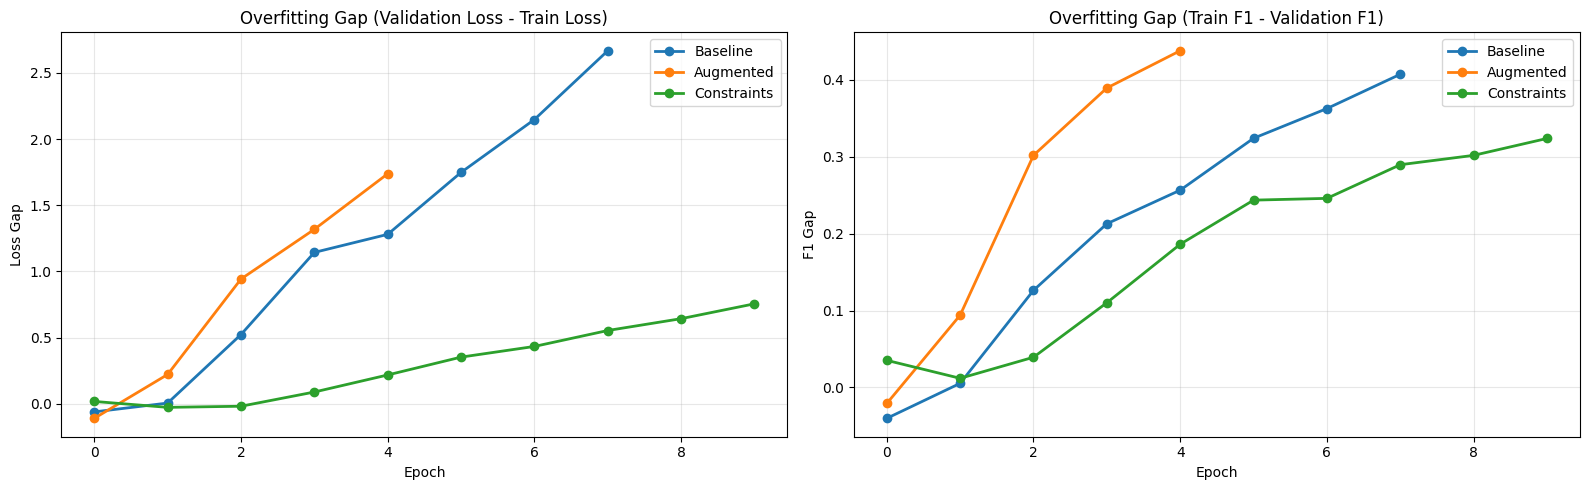

In [29]:
methods = ["baseline", "augmented", "constraints"]

# Compute loss gap for each method
gap_dict = {}
for method in methods:
    train_key = f'{method}_training_loss'
    val_key = f'{method}_validation_loss'
    
    if train_key in data_dict and val_key in data_dict:
        train_loss = data_dict[train_key]
        val_loss = data_dict[val_key]
        
        epochs = min(len(train_loss), len(val_loss))
        train_loss = train_loss[:epochs]
        val_loss = val_loss[:epochs]
        
        gap = [v - t for v, t in zip(val_loss, train_loss)]
        gap_dict[method] = gap

# Compute F1 gap for each method
f1_gap_dict = {}
for method in methods:
    train_key = f'{method}_training_f1'
    val_key = f'{method}_validation_f1'
    
    if train_key in data_dict and val_key in data_dict:
        train_f1 = data_dict[train_key]
        val_f1 = data_dict[val_key]
        
        epochs = min(len(train_f1), len(val_f1))
        train_f1 = train_f1[:epochs]
        val_f1 = val_f1[:epochs]
        
        gap = [t - v for t, v in zip(train_f1, val_f1)]
        f1_gap_dict[method] = gap

# Create combined figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot Loss Gap
for method, gap in gap_dict.items():
    ax1.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax1.set_title("Overfitting Gap (Validation Loss - Train Loss)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot F1 Gap
for method, gap in f1_gap_dict.items():
    ax2.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax2.set_title("Overfitting Gap (Train F1 - Validation F1)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Gap")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("combined_overfitting_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

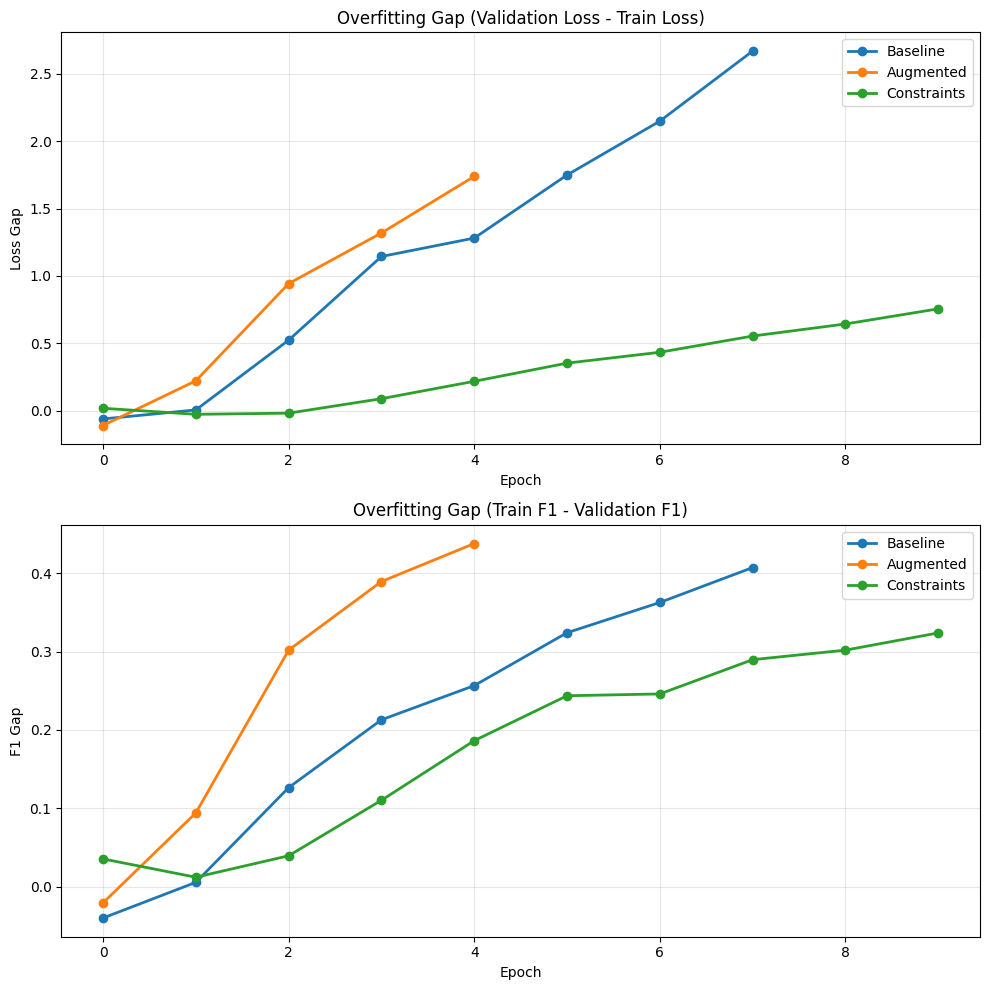

In [30]:
# Create combined figure with vertical stacking
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot Loss Gap
for method, gap in gap_dict.items():
    ax1.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax1.set_title("Overfitting Gap (Validation Loss - Train Loss)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss Gap")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot F1 Gap
for method, gap in f1_gap_dict.items():
    ax2.plot(range(len(gap)), gap, marker='o', linewidth=2, label=method.capitalize())

ax2.set_title("Overfitting Gap (Train F1 - Validation F1)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Gap")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()